# Do the biggest earnings beats keep drifting up for weeks? 📈
### SUE post-earnings drift — the textbook anomaly that quietly evaporates on big, liquid stocks

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Textbook PEAD replicates%3F: Busted](https://img.shields.io/badge/Textbook_PEAD_replicates%3F-Busted-8b949e?style=flat-square)

Open any markets textbook and you'll find *post-earnings-announcement drift*: after a company reports, the stock supposedly keeps sliding in the direction of the surprise for weeks. Sort names by how big the surprise was — the **standardized unexpected earnings**, or **SUE** — buy the top, short the bottom, and collect the drift. It's been called the *"granddaddy of anomalies."*

So does it work on 30 of the most-watched large-caps in the world? **No — and if anything it leans the other way.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebos and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 30-name large-cap basket, EPS surprises from SEC EDGAR, 2012-07-26→2026-06-03, 1,261 events. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sue_drift import data, strategy as st
try:
    from quantlab.repro import as_of
except Exception:
    as_of = lambda df, a: df[df.index <= pd.Timestamp(a)].copy()

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = as_of(data.load_prices(), data.AS_OF)
    EVENTS = data.load_events()
    ET = data.build_event_table(PRICES, EVENTS)
else:
    PRICES = EVENTS = ET = None
print("real cache present:", HAVE_REAL, "| SUE events:", (0 if ET is None else len(ET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'n_names': 30, 'filed_lo': '2012-07-26', 'filed_hi': '2026-06-03', 'fp': '4d0fd3625f76', 'h21': {'n': 1315, 'top': 1.06, 'bot': 2.22, 'ls': -1.16, 't': -2.29, 'nw_t': -1.41, 'win': 50.6, 'win_lo': 47.3, 'win_hi': 53.9, 'placebo_p': 0.991, 'block_p': 0.841, 'q5': [2.04, 1.91, 0.89, -0.05, 1.74]}, 'h42': {'n': 1279, 'top': 1.7, 'bot': 3.47, 'ls': -1.77, 't': -2.48, 'nw_t': -0.41, 'win': 46.9, 'win_lo': 43.6, 'win_hi': 50.3, 'placebo_p': 0.995, 'block_p': 0.913, 'q5': [3.37, 3.49, 2.48, 0.03, 2.69]}, 'h63': {'n': 1261, 'top': 3.34, 'bot': 4.29, 'ls': -0.95, 't': -1.12, 'nw_t': 0.41, 'win': 48.9, 'win_lo': 45.5, 'win_hi': 52.3, 'placebo_p': 0.879, 'block_p': 0.628, 'q5': [3.91, 4.48, 4.1, 1.16, 4.42]}, 'gross63': -0.95, 'c5_net': -1.27, 'c10_net': -1.47, 'decile63_ls': 1.53, 'decile63_t': 0.99, 'syn_null_mean': 0.08, 'syn_null_sd': 0.57, 'syn_null_fire': 0, 'syn_planted_ls': 16.6, 'syn_planted_t': 21.5}


real cache present: True | SUE events: 1319


## The answer first

| Question | Answer |
|---|---|
| Do the biggest positive surprises keep drifting up? | **No.** Over the next 1–3 months the top-SUE names actually drift **less** than the bottom-SUE names — the "buy winners, short losers" spread comes out **-0.9%** at 3 months (the *wrong* sign). |
| Is the sort at least orderly (more surprise → more drift)? | **No.** Line the names up from worst surprise to best and the drift zig-zags — the *lowest*-surprise bucket is among the *highest*-drifting. |
| Could it just be a fluke of how you slice it? | **It's worse than that.** Slice into 3 buckets and the spread is negative; slice into 10 and it's positive. A real pattern doesn't flip sign when you re-slice it. |
| Could you trade it? | **Nothing to trade.** The spread is negative before costs and more negative after. |

> The famous textbook drift is simply **not here** on big, liquid, heavily-covered names — which, it turns out, is exactly where the research says it should be weakest.

## 1 · The claim

> *"When a company reports earnings, the market underreacts. A big beat keeps drifting up for weeks; a big miss keeps sliding. So rank stocks by how surprising their earnings were, buy the top, short the bottom, and pocket the drift."*

The surprise is measured as **SUE** — take this quarter's earnings per share, subtract the *same quarter a year ago* (that's the "expected" number under the simplest model), and divide by how bumpy that year-over-year change has been lately. A SUE of +3 means "a beat three times bigger than this company's usual wobble." This is the original Foster-Olsen-Shevlin / Bernard-Thomas signal from the 1980s.

## 2 · So what?

If it worked, it would be one of the cleanest signals in finance: earnings dates are known in advance, the surprise is a hard accounting number, and the trade is mechanical. It's also one of the most-studied anomalies ever — which is exactly why it's worth re-checking on modern, liquid names. Anomalies that everyone knows about and that live in big tradeable stocks tend to get arbitraged into the ground.

## 3 · How would we even know?

- **The sort.** Every quarterly report from 30 large-caps (1,261 events since 2012), each tagged with its SUE, computed only from data known *before* the report.
- **The drift.** Buy (or short) the day *after* the report is public — no peeking — and hold 1, 2 or 3 months.
- **The spread.** Top third minus bottom third. If the textbook is right it's clearly positive and gets bigger for bigger surprises.
- **The honesty checks.** Reports bunch up in earnings season, so we re-test on a "calendar-time" basis, shuffle the labels thousands of times, and re-slice the sort to see if the answer is stable.

## 4 · The teardown — let's actually look

**First, the headline spread** at three horizons: top-SUE third minus bottom-SUE third.

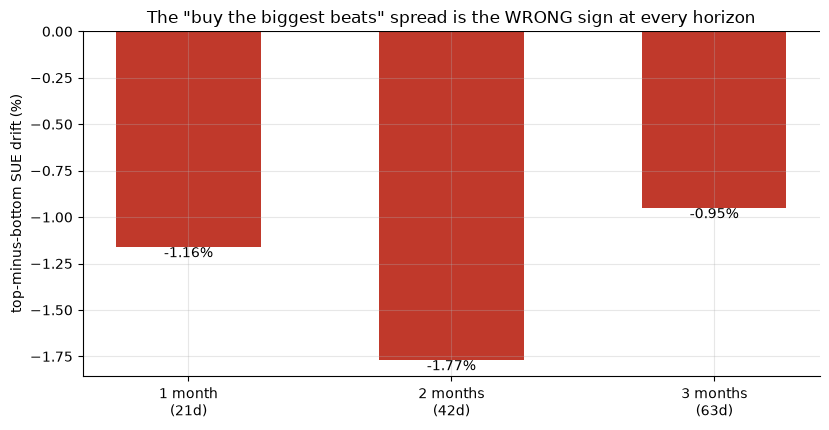

{21: -1.16, 42: -1.77, 63: -0.95}


In [2]:
hs = {}
for H in st.HORIZONS:
    if HAVE_REAL:
        ls = st.long_short_drift(st.event_drift_frame(PRICES, ET, H), n_buckets=3)
        hs[H] = ls['ls_mean']*100
    else:
        hs[H] = R[f'h{H}']['ls']
labels = ['1 month\n(21d)','2 months\n(42d)','3 months\n(63d)']
vals = [hs[H] for H in st.HORIZONS]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(labels, vals, color=[RED, RED, RED], width=.55)
for i,v in enumerate(vals): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('top-minus-bottom SUE drift (%)')
ax.set_title('The "buy the biggest beats" spread is the WRONG sign at every horizon')
plt.tight_layout(); plt.show()
print({H: round(v,2) for H,v in hs.items()})

Every bar is **below zero**. At three months the spread is **-0.9%** — the top-SUE names drifted *less* than the bottom-SUE names. That's the opposite of what the anomaly predicts.

**Is the sort at least orderly?** A real drift climbs steadily from the worst surprises to the best. Here are the five buckets, worst SUE on the left:

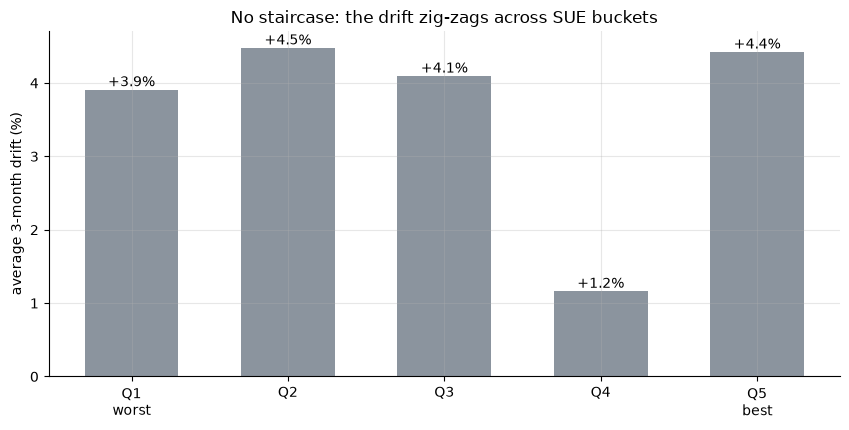

[3.91, 4.48, 4.1, 1.16, 4.42]


In [3]:
H = 63
if HAVE_REAL:
    q5 = st.bucket_means(st.event_drift_frame(PRICES, ET, H), n_buckets=5)*100
else:
    q5 = np.array(R['h63']['q5'])
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['Q1\nworst','Q2','Q3','Q4','Q5\nbest'], q5, color=GREY, width=.6)
for i,v in enumerate(q5): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('average 3-month drift (%)')
ax.set_title('No staircase: the drift zig-zags across SUE buckets')
plt.tight_layout(); plt.show()
print([round(float(x),2) for x in q5])

There's no staircase. The *lowest*-surprise bucket (Q1) is one of the *highest*-drifting, the 4th bucket is a trough, and the "best" bucket is nowhere near the top. A signal that behaved like this in a job interview would not get hired.

**The tell that it's noise:** re-slice the exact same sort into 10 buckets instead of 3, and the spread flips sign.

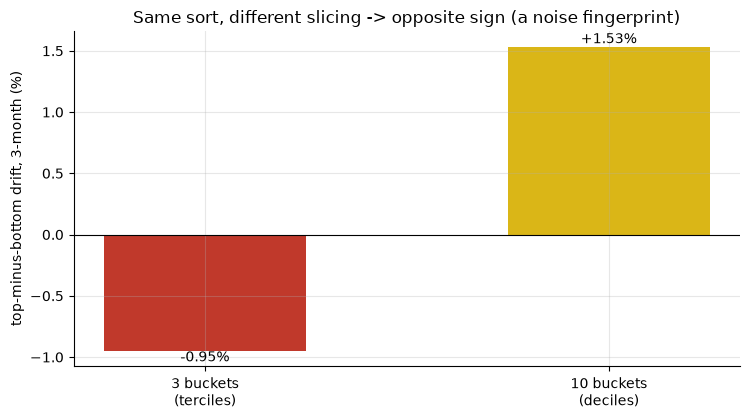

tercile -0.95%  |  decile +1.53%


In [4]:
if HAVE_REAL:
    fr = st.event_drift_frame(PRICES, ET, 63)
    terc = st.long_short_drift(fr, n_buckets=3)['ls_mean']*100
    dec = st.long_short_drift(fr, n_buckets=10)['ls_mean']*100
else:
    terc, dec = R['h63']['ls'], R['decile63_ls']
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['3 buckets\n(terciles)','10 buckets\n(deciles)'], [terc, dec],
       color=[RED, AMBER], width=.5)
for i,v in enumerate([terc, dec]): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('top-minus-bottom drift, 3-month (%)')
ax.set_title('Same sort, different slicing -> opposite sign (a noise fingerprint)')
plt.tight_layout(); plt.show()
print(f'tercile {terc:+.2f}%  |  decile {dec:+.2f}%')

Terciles say **-0.9%**, deciles say **+1.5%** — and neither is statistically distinguishable from zero. A genuine anomaly keeps its sign when you re-slice it; noise doesn't.

## 5 · The verdict

- **Signal — None.** Sorted on SUE, the drift is the wrong sign at 1–3 months, the buckets don't line up, and the sign flips when you re-slice. Once you account for the fact that earnings bunch into seasons, there's no real spread left in either direction.
- **Tradability — Mirage.** Negative before costs, more negative after. There's nothing to collect.
- **Does the textbook drift replicate here? — Busted.** On big, liquid, heavily-covered names — exactly where decades of research say the drift should be weakest — it's simply gone.

## 6 · Going further 🚪

- **Where the drift probably still lives:** small, illiquid, thinly-covered stocks — the classic finding is that PEAD concentrates there and fades among liquid large-caps (the opposite of our basket). A natural follow-up is a small-cap version.
- **Why big caps are the graveyard:** they're followed by armies of analysts and arbitraged in seconds; any drift gets competed away long before you could hold it for months.
- **Sibling studies:** [363-pead-drift](../../363-pead-drift/) sorts on the *price jump* around the report instead of the earnings number; [369-earnings-revision-momentum](../../369-earnings-revision-momentum/) sorts on *analyst revisions*; [534-revenue-surprise-drift](../../534-revenue-surprise-drift/) does this exact test on *revenue* surprises (also empty). See [docs/references.md](../docs/references.md) for the full dedup.

*Think the SUE drift is alive on a universe we didn't test? Show a monotone, robust, certifiable spread after realistic costs on the size you'd actually run — then we'll talk.*